In [100]:
# =============================
# Useful Imports
# =============================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars
from matplotlib.ticker import FuncFormatter

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Kaggle and Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

In [101]:
# Import Filtered, Cleaned, and Imputed Zillow Data

df_imputed = pd.read_csv("zillow_dataset_imputed.csv")

In [102]:
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76557 entries, 0 to 76556
Data columns (total 30 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   bathroomcnt                   76557 non-null  float64
 1   bedroomcnt                    76557 non-null  float64
 2   buildingqualitytypeid         76557 non-null  int64  
 3   calculatedbathnbr             76557 non-null  float64
 4   calculatedfinishedsquarefeet  76557 non-null  int64  
 5   finishedsquarefeet12          76557 non-null  int64  
 6   fireplacecnt                  76557 non-null  int64  
 7   fullbathcnt                   76557 non-null  float64
 8   garagecarcnt                  76557 non-null  int64  
 9   garagetotalsqft               76557 non-null  int64  
 10  hashottuborspa                76557 non-null  int64  
 11  heatingorsystemtypeid         76557 non-null  int64  
 12  lotsizesquarefeet             76557 non-null  int64  
 13  p

**PART 4.A - Investigate Feature Relationships:**

In [103]:
# Select Numeric Columns

numeric_cols = df_imputed.select_dtypes(include = "number").columns

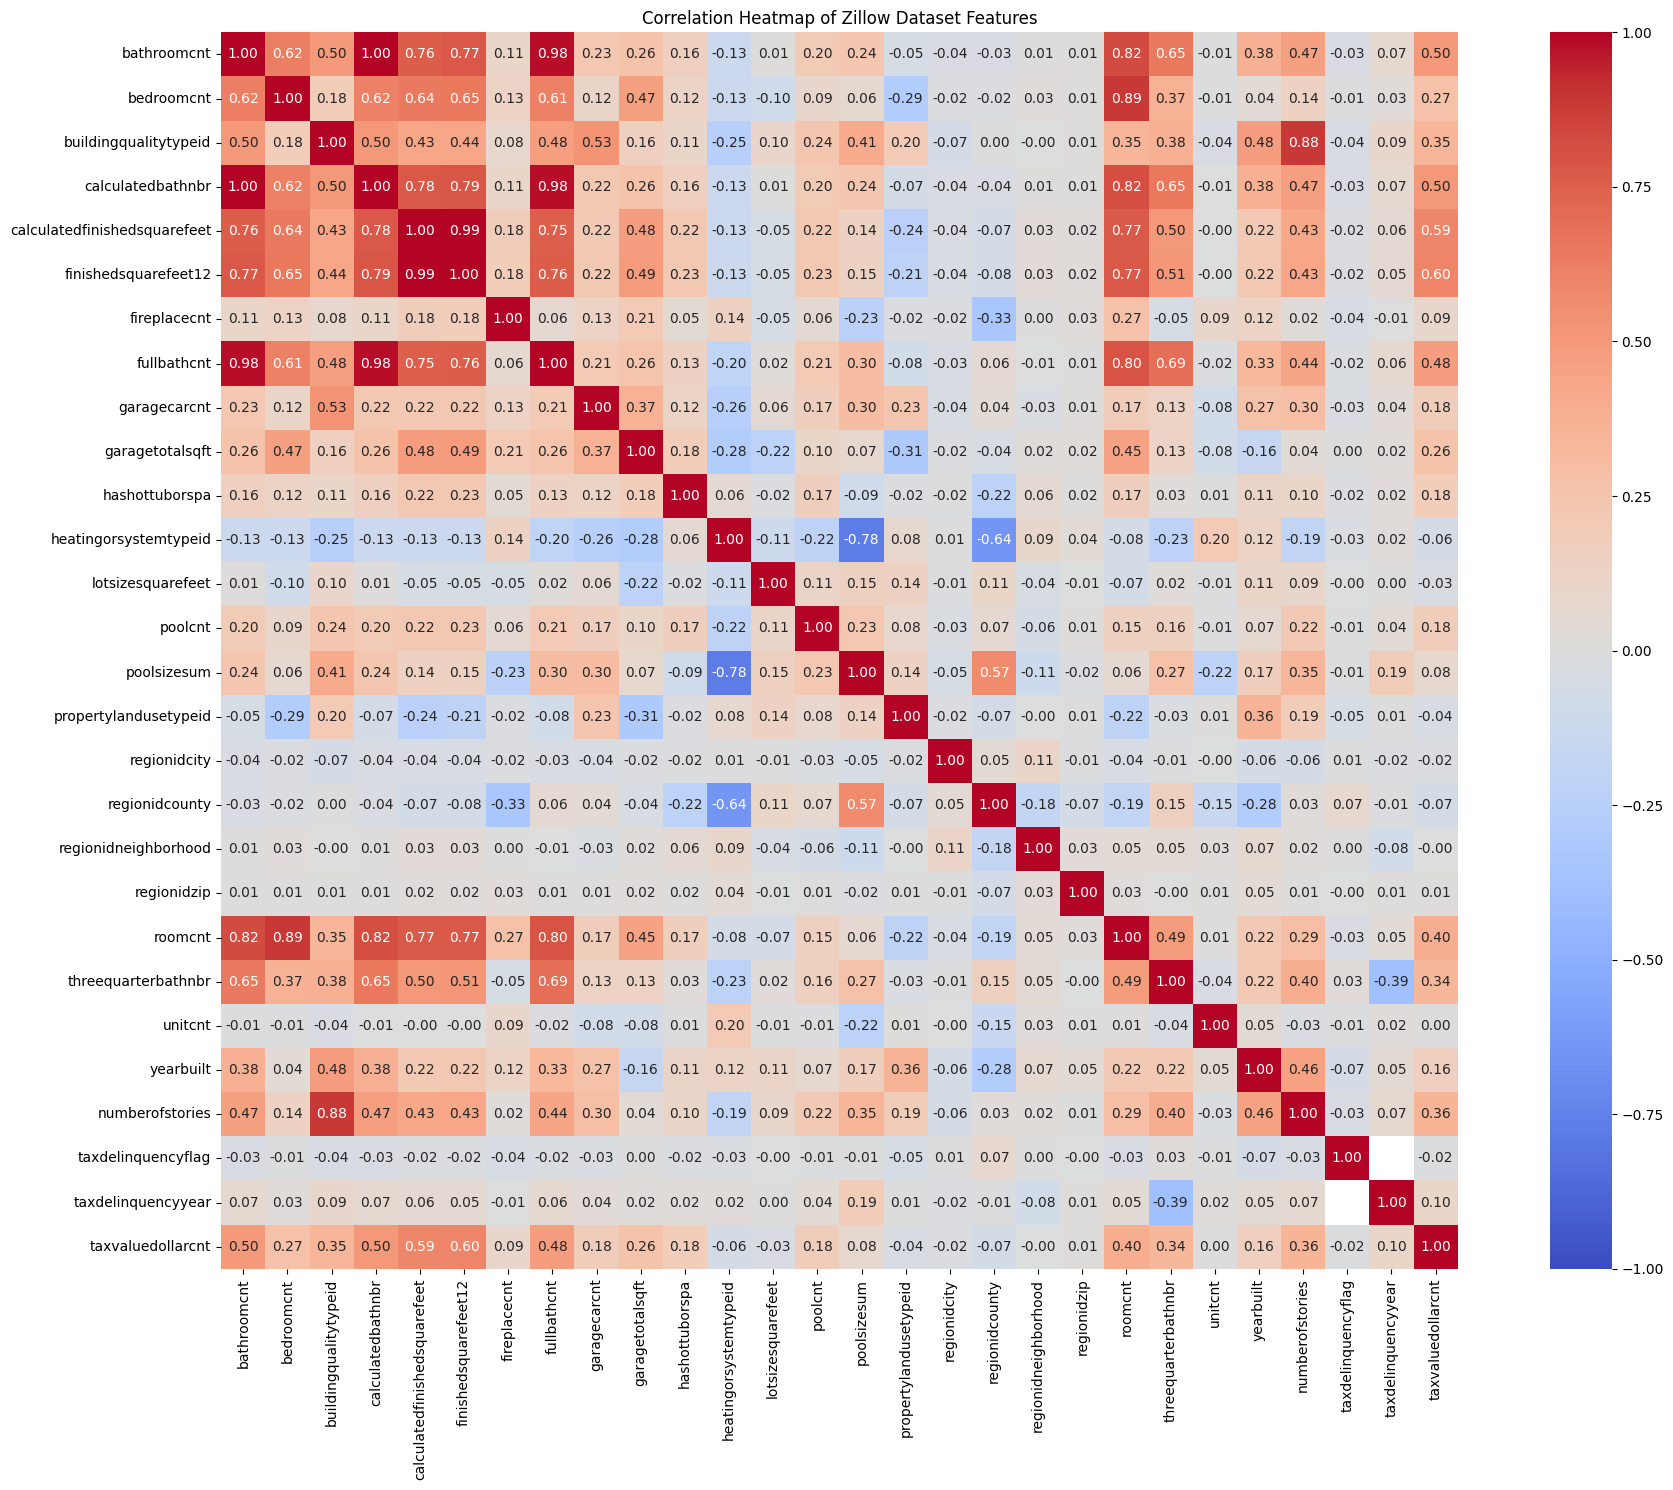

In [104]:
# Heat Map of Correlation Matrix

corr = df_imputed[numeric_cols].corr()

plt.figure(figsize = (20, 15))

sns.heatmap(corr, annot = True, fmt = ".2f", cmap = "coolwarm", vmin = -1, vmax = 1, square = True)

plt.title("Correlation Heatmap of Zillow Dataset Features")
plt.tight_layout()

None

**Part 4.A Discussion - Heat Map:**

The Heat Map shows almost perfect correlations between `bathroomcnt`, `calculatedbathnbr`, and `fullbathcnt`. This is not unexpected given that one feature measures the number of rooms that are bathrooms, the second measures the total number of bathrooms, presumably counting 1 for a full bath and 0.5 for a half bath, and the third lists the number of full bathrooms. All three features move linearly together in the same direction, and are going to be highly redundant. We should be able to safely select one and drop the remaining two for our analysis. Also, `threequarterbathnbr` is highly correlated to the other bathroom count variables, and is similarly going to be redundant.

The variable `roomcnt` shows high linear correlation with `bathroomcnt`, `bedroomcnt`, and `finishedsquarefeet`. This again makes sense, as increasing the number of bedrooms and bathrooms will also increase the number of total rooms in the property, and the number of total rooms should also grow or shrink with the size of the finished space. `roomcnt` may be redundant.

Features that measure the size of the property also show high correlation to each other. `finishedsquarefeet12`, which is the finished living area square footage, and `calculatedfinishedsquarefeet`, defined as total finished living area square footage, sound like the same variable and have a correlation to each other of 0.99. Again, we should be able to pick just one of these features to use in our analysis.

It is interesting that `lotsizesquarefeet` does not appear to have a strong linear relationship with any of the other features, or with the target variable. Could there be a non-linear relationship that the correlation matrix is not capturing?

In [105]:
# Compute F-Statistic for all Features

X = df_imputed[numeric_cols].drop(["taxvaluedollarcnt", "taxdelinquencyyear"], axis = 1)
y = df_imputed["taxvaluedollarcnt"]

f_vals, p_vals = f_regression(X, y)

f_results = pd.Series(f_vals, index = X.columns).sort_values(ascending = False)
f_results

,0
finishedsquarefeet12,42670.840211
calculatedfinishedsquarefeet,41588.124381
calculatedbathnbr,25701.285790
bathroomcnt,24974.342680
fullbathcnt,23081.733867
roomcnt,14260.422394
numberofstories,11316.503866
buildingqualitytypeid,10372.146663
threequarterbathnbr,10075.676241
bedroomcnt,6011.596438


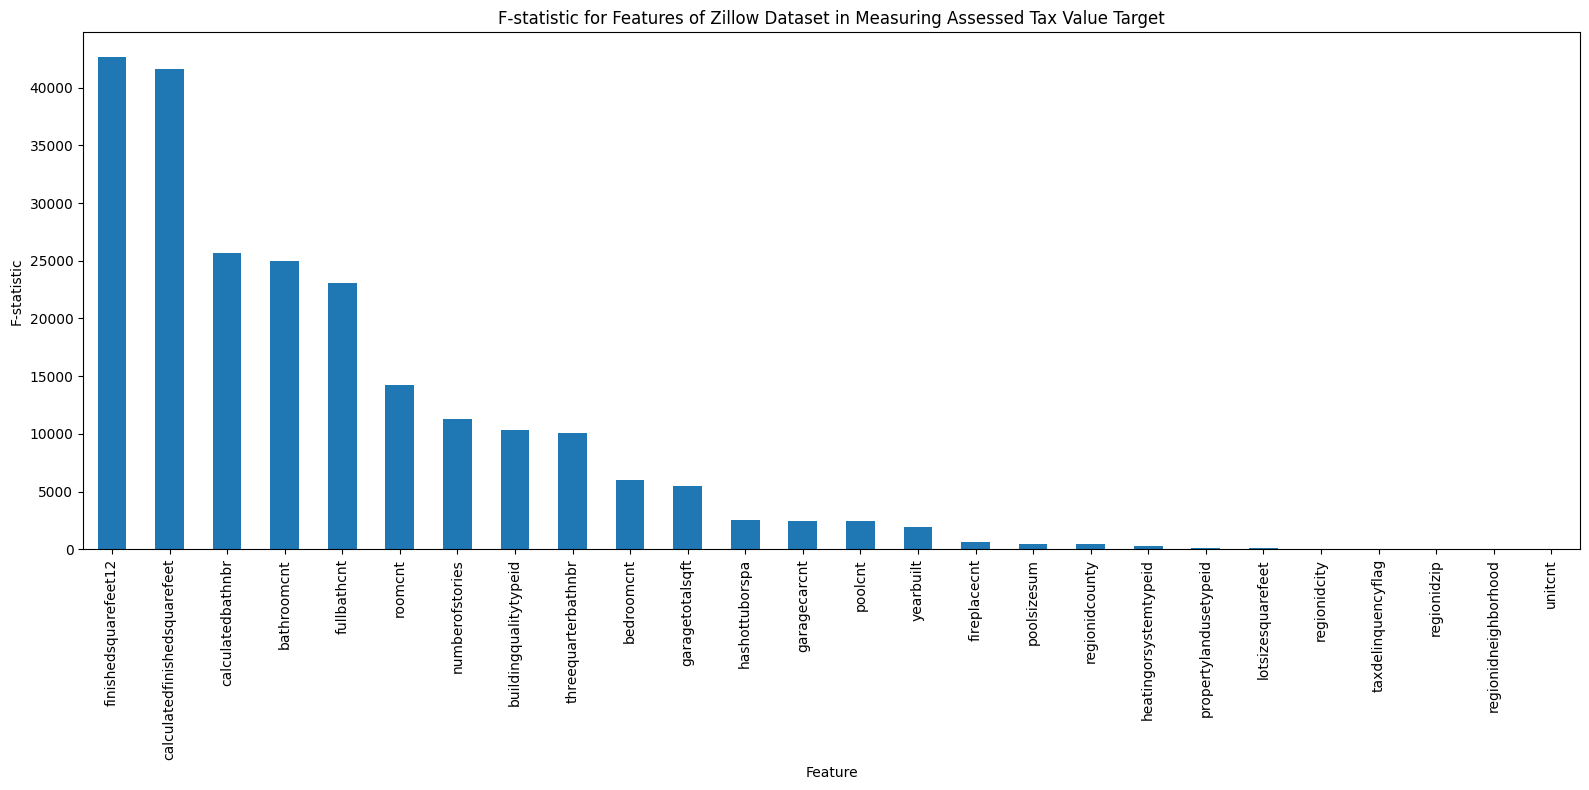

In [106]:
# Make a Bar Chart of the F-Statistic for each Feature

plt.figure(figsize = (16, 8))

f_results.plot(kind = "bar")

plt.ylabel("F-statistic")
plt.xlabel("Feature")
plt.title("F-statistic for Features of Zillow Dataset in Measuring Assessed Tax Value Target")
plt.xticks(rotation = 90)

plt.tight_layout()
plt.show()

**Part 4.A Discussion - F-Statistic:**

The F-statistic indicates how strongly each individual feature is related to the target variable, by looking at variation within each feature across different target outcomes. A large F-statistic means that the feature likely contains information that is useful for predicitng the target variable.

Features that were highly correlated in the Heat Map Correlation Matrix, have similar F-statistics. These include:

1.   `finishedsquarefeet12` and `calculatedfinishedsquarefeet`
2.   `calculatedbathnbr`, `bathroomcnt`, and `fullbathcnt`
3.    `numberofstories` and `buildingqualitytypeid`

Again, it seems like some of these variable pairs might be redundant and could be dropped for future analysis.

Additionally, it seems like the features that are emost useful in predicting the target variable are related to the general size of the home, while location and other amenities may be less important. `finishedsquarefeet`, `calculatedbathnbr`, `roomcnt`, `numberofstories`, `bedroomcnt`, and even `garagetotalsqft` all seem to have the biggest impact on the assessed tax value.

There is a bit of a drop in the F-statistic values for amenity features like pools and fireplaces. Features that indicate region and location like county, city, and zip-code are non-ordinal and have not yet been encoded, so it makes sense that they would have a low F-statistic. Interestingly, total lot size does not carry a high F-statistic, and it seems that the size of the house might be a lot more imprtant than the size of the land.

In [107]:
# Forward Feature Selection

def forward_feature_selection(X, y, model,
                              scoring = 'neg_root_mean_squared_error',
                              cv = 5,
                              tol = None,             # None = no delta cutoff
                                                      # use 0.0 for "no further improvements"
                                                      # and 1e-4 for "point of diminishing returns"
                              max_features = None,    # None = use all features
                              n_jobs = -1,
                              verbose = False
                             ):
    selected_features = []                            # List to store the order of features selected
    remaining_features = list(X.columns)              # Features not yet selected
    best_scores = []                                  # List to store the CV score after each feature addition
    previous_score = float('inf')                     # Initialize previous score for improvement comparison

    # Track the best subset of features and its corresponding score

    best_feature_set = None                           # Best combination of features found so far
    best_score = float('inf')                         # Best CV score observed so far

    while remaining_features:
        scores = {}                                   # Dictionary to hold CV scores for each candidate feature
        for feature in remaining_features:
            current_features = selected_features + [feature]

            # Compute the CV score for the current set of features (negated RMSE, so lower is better)
            cv_score = -cross_val_score(model, X[current_features], y,
                                        scoring = scoring, cv = cv, n_jobs = n_jobs
                                       ).mean()
            scores[feature] = cv_score

        # Select the feature that minimizes the CV score
        best_feature = min(scores, key = scores.get)
        current_score = scores[best_feature]

        # Check if the improvement is significant based on the tolerance (tol)
        if tol is not None and previous_score - current_score < tol:
            if verbose:
                print("Stopping early due to minimal improvement.")
            break

        # Add the best feature to the selected list and update score trackers
        selected_features.append(best_feature)
        best_scores.append(current_score)
        remaining_features.remove(best_feature)
        previous_score = current_score

        if verbose:
            print(f"\nFeatures: {selected_features[-3:]}, CV Score (RMSE): {current_score:.4f}")

        # Update the best subset if the current score is better than the best so far
        if current_score < best_score:
            best_score = current_score
            best_feature_set = selected_features.copy()

        # Check if the maximum number of features has been reached
        if max_features is not None and len(selected_features) >= max_features:
            break

    return (
        selected_features,      # List of features in the order they were selected (this will be ALL features if max_features == None
        best_scores,            # List of cross-validation scores corresponding to each addition in the previous list
        best_feature_set,       # The subset of features that achieved the best CV score.
        best_score              # The best CV score
    )

In [108]:
# Define Features and Target

X = df_imputed[numeric_cols].drop(["taxvaluedollarcnt", "taxdelinquencyyear"], axis = 1)
y = df_imputed["taxvaluedollarcnt"]


Features: ['finishedsquarefeet12'], CV Score (RMSE): 335867.2762

Features: ['finishedsquarefeet12', 'bedroomcnt'], CV Score (RMSE): 329459.5035

Features: ['finishedsquarefeet12', 'bedroomcnt', 'bathroomcnt'], CV Score (RMSE): 327092.8842

Features: ['bedroomcnt', 'bathroomcnt', 'numberofstories'], CV Score (RMSE): 326305.5764

Features: ['bathroomcnt', 'numberofstories', 'poolsizesum'], CV Score (RMSE): 325458.7034

Features: ['numberofstories', 'poolsizesum', 'yearbuilt'], CV Score (RMSE): 324619.9777

Features: ['poolsizesum', 'yearbuilt', 'propertylandusetypeid'], CV Score (RMSE): 324010.8241

Features: ['yearbuilt', 'propertylandusetypeid', 'roomcnt'], CV Score (RMSE): 323571.8500

Features: ['propertylandusetypeid', 'roomcnt', 'regionidcounty'], CV Score (RMSE): 323085.5220

Features: ['roomcnt', 'regionidcounty', 'heatingorsystemtypeid'], CV Score (RMSE): 322573.8765

Features: ['regionidcounty', 'heatingorsystemtypeid', 'regionidneighborhood'], CV Score (RMSE): 322338.7090

F

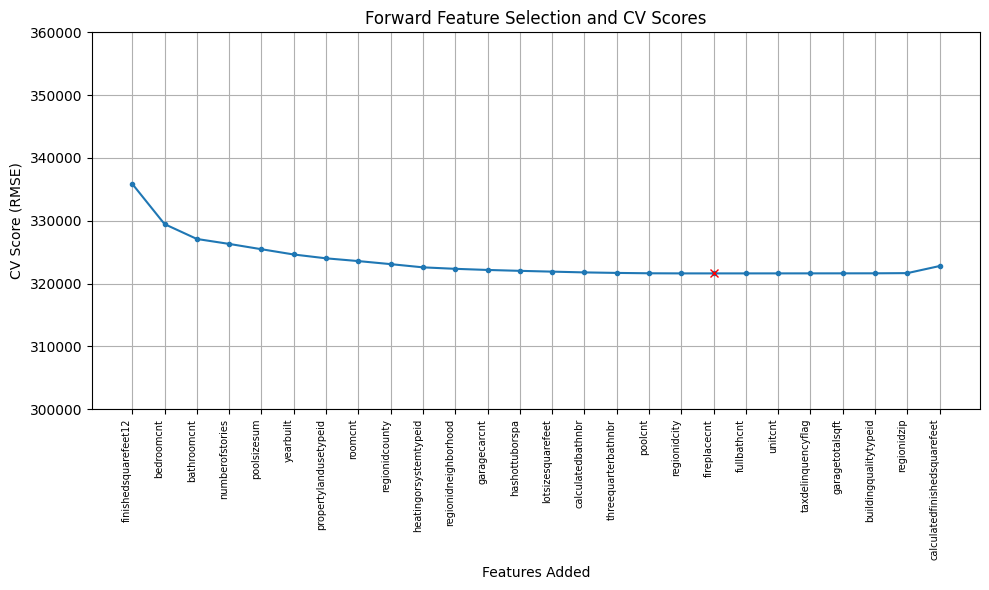

Best Features: ['finishedsquarefeet12', 'bedroomcnt', 'bathroomcnt', 'numberofstories', 'poolsizesum', 'yearbuilt', 'propertylandusetypeid', 'roomcnt', 'regionidcounty', 'heatingorsystemtypeid', 'regionidneighborhood', 'garagecarcnt', 'hashottuborspa', 'lotsizesquarefeet', 'calculatedbathnbr', 'threequarterbathnbr', 'poolcnt', 'regionidcity', 'fireplacecnt']
Best CV Score: 321609.8021


In [62]:
# Run Forward Feature Selection

from sklearn.linear_model import LinearRegression

model = LinearRegression()

selected_features, best_scores, best_forward_features, best_forward_score = (forward_feature_selection(X, y, model, verbose = True))

# Plot the results

index = np.argmax(np.array(selected_features) == best_forward_features[-1])

plt.figure(figsize = (10, 6))
plt.plot(range(1, len(best_scores) + 1), best_scores, marker = '.')
plt.plot([index + 1], best_forward_score, marker = 'x', color = 'red')
plt.xticks(range(1, len(selected_features) + 1), selected_features, rotation = 90, ha = 'right', fontsize = 7)
plt.title('Forward Feature Selection and CV Scores')
plt.xlabel('Features Added')
plt.ylabel('CV Score (RMSE)')
plt.grid()

# Change scale of y-axis to better see better see the behavior around the minimum point
plt.ylim(300000, 360000)

plt.tight_layout()
plt.show()

# Print the best subset and score
print(f"Best Features: {best_forward_features}")
print(f"Best CV Score: {best_forward_score:.4f}")

In [16]:
# Backward Feature Selection

def backward_feature_selection(X, y, model,
                               scoring = 'neg_root_mean_squared_error',
                               cv = 5,
                               tol = None,             # None = no delta cutoff
                                                       # use 0.0 for "no further improvements"
                                                       # and 1e-4 for "point of diminishing returns"
                               max_features = None,    # If None, remove features until only 1 remains
                                                       # Otherwise, stop when this many features remain
                               n_jobs = -1,
                               verbose = True
                              ):

    # Helper function to compute CV score using LinearRegression
    def cv_score(features):
        return -cross_val_score(model, X[features], y,
                                scoring = scoring, cv = cv,
                                n_jobs = n_jobs).mean()

    # Start with all features (using a list for easier manipulation)
    features_remaining = list(X.columns)

    # Compute initial CV score with the full feature set
    initial_score = cv_score(features_remaining)

    # Initialize tracking variables
    best_score        = initial_score                # Best (lowest) CV score observed so far
    best_feature_set  = features_remaining.copy()    # Feature set corresponding to best_score
    selected_features = ['NONE']                     # List to record the order in which features are removed
    best_scores       = [initial_score]              # List to record the CV score after each removal (starting with full set)

    if verbose:
        print("Start with full set of features:")
        print(f'{features_remaining}  CV score (RMSE): {np.around(initial_score, 4)}\n')

    # Determine the target number of features to keep:
    # For backward elimination, if max_features is None, we remove until 1 feature remains.
    target_feature_count = 1 if max_features is None else max_features

    prev_score = initial_score
    round_num = 1
    # Continue removing features until we reach the target count
    while len(features_remaining) > target_feature_count:
        if verbose:
            print(f'Round {round_num}:')

        # Initialize variables to track the best removal in this round
        lowest_score = float('inf')
        feature_to_remove = None
        best_new_features = None

        # Try removing each feature one at a time
        for feature in features_remaining:
            new_feature_set = features_remaining.copy()
            new_feature_set.remove(feature)
            new_score = cv_score(new_feature_set)
            if verbose:
                print('Trying removal of:',feature, np.around(new_score, 4))
            if new_score < lowest_score:
                lowest_score = new_score
                feature_to_remove = feature
                best_new_features = new_feature_set

        # Check if improvement is significant enough (if tol is set)
        if tol is not None and (prev_score - lowest_score) < tol:
            if verbose:
                print("\nStopping early due to minimal improvement.")
            break

        # Update the best score and feature set if current removal improves performance
        if lowest_score < best_score:
            best_score = lowest_score
            best_feature_set = best_new_features.copy()

        # Update trackers for this round
        prev_score = lowest_score
        features_remaining = best_new_features
        selected_features.append(feature_to_remove)
        best_scores.append(lowest_score)

        if verbose:
            print(f'\nRemoving {feature_to_remove}:  CV score (RMSE) {np.around(lowest_score, 4)}\n')
        round_num += 1

    return (
        selected_features,      # Order in which features were removed
        best_scores,            # CV scores after each removal step
        best_feature_set,       # Feature set that achieved the best CV score
        best_score              # Best (lowest) CV score
    )

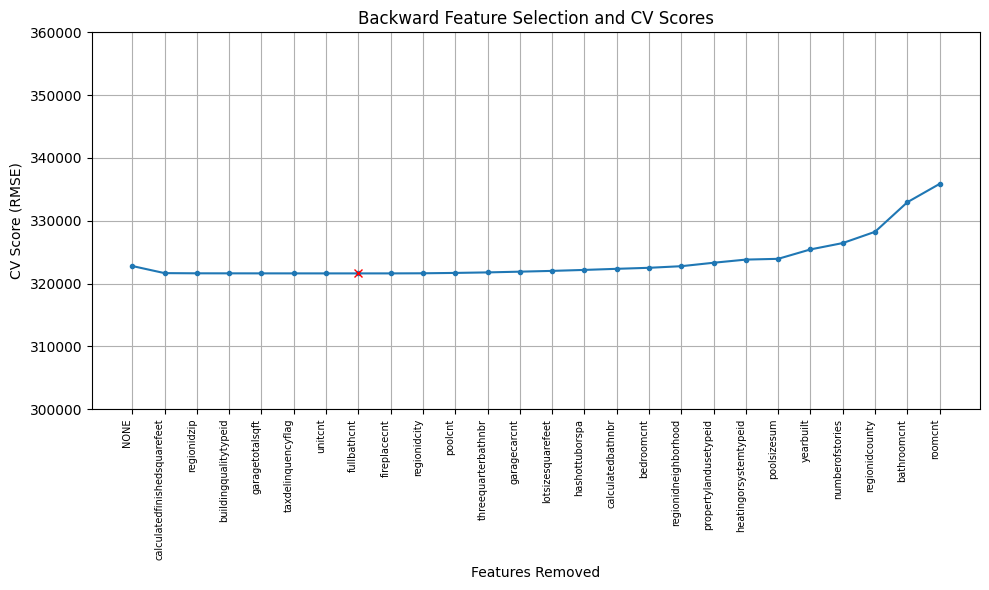

Best feature set: ['bathroomcnt', 'bedroomcnt', 'calculatedbathnbr', 'finishedsquarefeet12', 'fireplacecnt', 'garagecarcnt', 'hashottuborspa', 'heatingorsystemtypeid', 'lotsizesquarefeet', 'poolcnt', 'poolsizesum', 'propertylandusetypeid', 'regionidcity', 'regionidcounty', 'regionidneighborhood', 'roomcnt', 'threequarterbathnbr', 'yearbuilt', 'numberofstories']
CV score (RMSE): 321609.8021


In [63]:
# Run Backward Feature Selection

model = LinearRegression()

selected_features, best_scores, best_feature_set, best_backward_score = (backward_feature_selection(X, y, model, verbose = False))

# Plot the results

plt.figure(figsize = (10, 6))
plt.title('Backward Feature Selection and CV Scores')
plt.plot(range(1, len(best_scores) + 1), best_scores, marker = '.')
index = np.argmin(best_scores)
plt.plot([index + 1], best_scores[index], marker = 'x', color = 'red')
plt.xticks(range(1, len(selected_features) + 1), selected_features, rotation = 90, ha = 'right', fontsize=7)
plt.xlabel('Features Removed')
plt.ylabel('CV Score (RMSE)')

plt.ylim(300000, 360000)

plt.grid()
plt.tight_layout()
plt.show()

# Print the best subset and cv score

print("Best feature set:", best_feature_set)
print("CV score (RMSE):", np.around(best_backward_score, 4))

**Part 4.A Discussion - Forward and Backward Feature Selection:**

Both forward and backward feature selection using all cleaned and imputed features with linear regression yield the same Root Mean Squared Error (RMSE) of 321,609.80. The RMSE feels high, but that could be due to the model being used, and linear regression may not be the best model for this problem and dataset.

Ultimately, a some type of decision tree model (Random Forest, Gradient Boosting, etc.) could be a good choice for this dataset, as it would be able to implicitly perform feature selection and handle the different data types, magnitudes, and skewed distributions.

Forward and backward feature selection also identified the same seven features to remove as follows:
`calculatedfinishedsquarefeet`
`regionidzip`
`buildingqualitytypeid`
`garagetotalsqft`
`taxdelinquencyflag`
`unitcnt`
`fullbathcnt`

****PART 4.B - 2-Dimensional Visualizations for Interesting Patterns:****

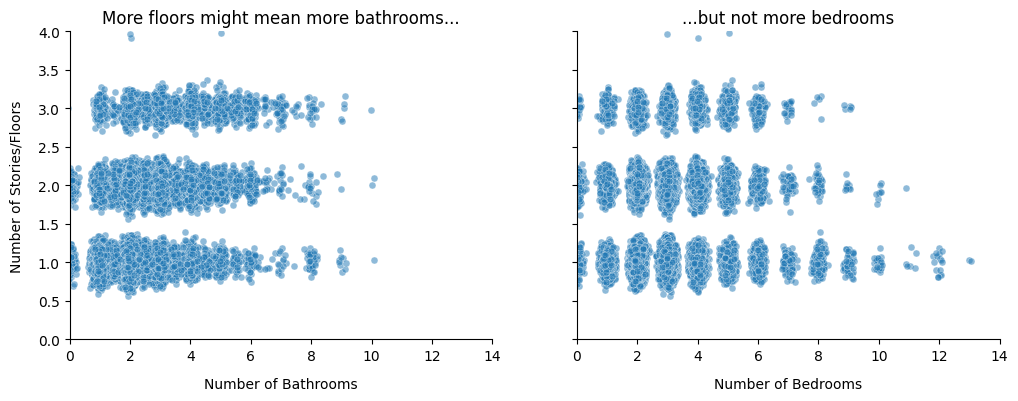

In [163]:
# Scatterplots of Number of Stories vs. Full Bathroom and Bedroom Counts

# Add jitter manually
np.random.seed(42)
jittered_bath = df_imputed["bathroomcnt"] + np.random.normal(0, 0.1, len(df_imputed))
jittered_bed = df_imputed["bedroomcnt"] + np.random.normal(0, 0.1, len(df_imputed))
jittered_floors = df_imputed["numberofstories"] + np.random.normal(0, 0.1, len(df_imputed))


plt.subplots(1, 2, figsize = (12, 4), sharey = True)

plt.subplot(1, 2, 1)

ax = sns.scatterplot(x = jittered_bath, y = jittered_floors, data = df_imputed, s = 25, alpha = 0.5)

ax.spines[["top", "right"]].set_color("none")
ax.set_xlabel("Number of Bathrooms", labelpad = 10)
ax.set_ylabel("Number of Stories/Floors", labelpad = 10)
ax.set_title("More floors might mean more bathrooms...")
ax.set_xlim(0, 14)
ax.set_ylim(0, 4)


plt.subplot(1, 2, 2)

ax = sns.scatterplot(x = jittered_bed, y = jittered_floors, data = df_imputed, s = 25, alpha = 0.5)

ax.spines[["top", "right"]].set_color("none")
ax.set_xlabel("Number of Bedrooms", labelpad = 10)
ax.set_ylabel("Number of Stories/Floors", labelpad = 10)
ax.set_title("...but not more bedrooms")
ax.set_xlim(0, 14)
ax.set_ylim(0, 4)

None

**Discussion:**

The three features used in the scatterplots above are all discrete quantitative variables, meaning they are numeric but can only take on specific values. We did apply a jitter to spread the observations out a bit, but they still appear in clusters since the variables are not continuous.

The plot on the left shows the relationship between `numberofstories` and `bathroomcnt`, which we know have a correlation of 0.47. This small positive linear relationship is somewhat visible in the scatter plot, and more floors has a slight trend towards more bathrooms. Also, it appears that there are properties with 0 bathrooms, and perhaps these samples should be dropped from our analysis.

The plot on the right displays the relationship between `numberofstories` and `bedroomcnt`, which only have a correlation of 0.14. It does not appear that the number of floors has any type of linear relationship with the number of bedrooms.

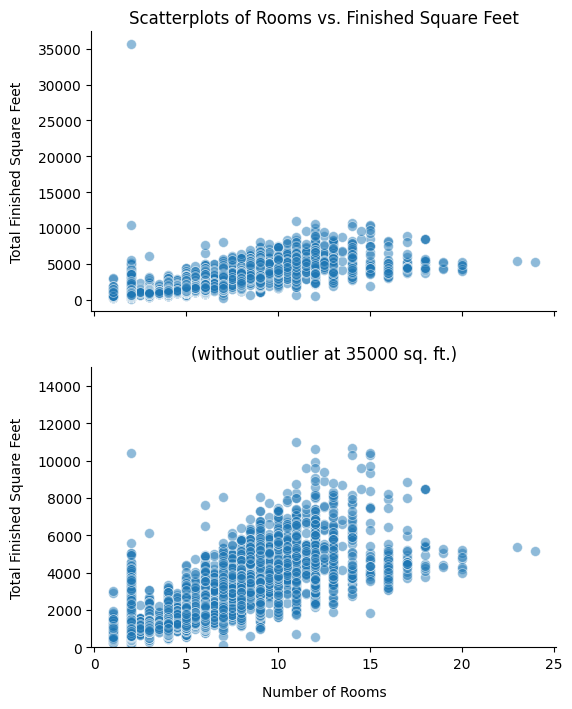

In [152]:
# Scatterplots of Room Count and Total Finished Square Feet

plt.subplots(2, 1, figsize = (6, 8), sharex = True)

plt.subplot(2, 1, 1)

ax = sns.scatterplot(x = "roomcnt", y = "calculatedfinishedsquarefeet", data = df_imputed, s = 50, alpha = 0.5)

ax.spines[["top", "right"]].set_color("none")
ax.set_ylabel("Total Finished Square Feet", labelpad = 10)
ax.set_title("Scatterplots of Rooms vs. Finished Square Feet")


plt.subplot(2, 1, 2)

ax = sns.scatterplot(x = "roomcnt", y = "calculatedfinishedsquarefeet", data = df_imputed, s = 50, alpha = 0.5)

ax.spines[["top", "right"]].set_color("none")
ax.set_xlabel("Number of Rooms", labelpad = 10)
ax.set_ylabel("Total Finished Square Feet", labelpad = 10)
ax.set_title("(without outlier at 35000 sq. ft.)")

ax.set_ylim(0, 15000)

None



**Discussion:**

The scatter plots above both show the relationship between `calculatedfinishedsquarefeet` and `roomcnt`, which have a strong positive linear correlation of 0.77. Removing the outlier sample that has around 35000 finished square feet, the second plot on the bottom is scaled to better show this positive linear relationship. This intuitively makes sense: larger properties should generally have more rooms.

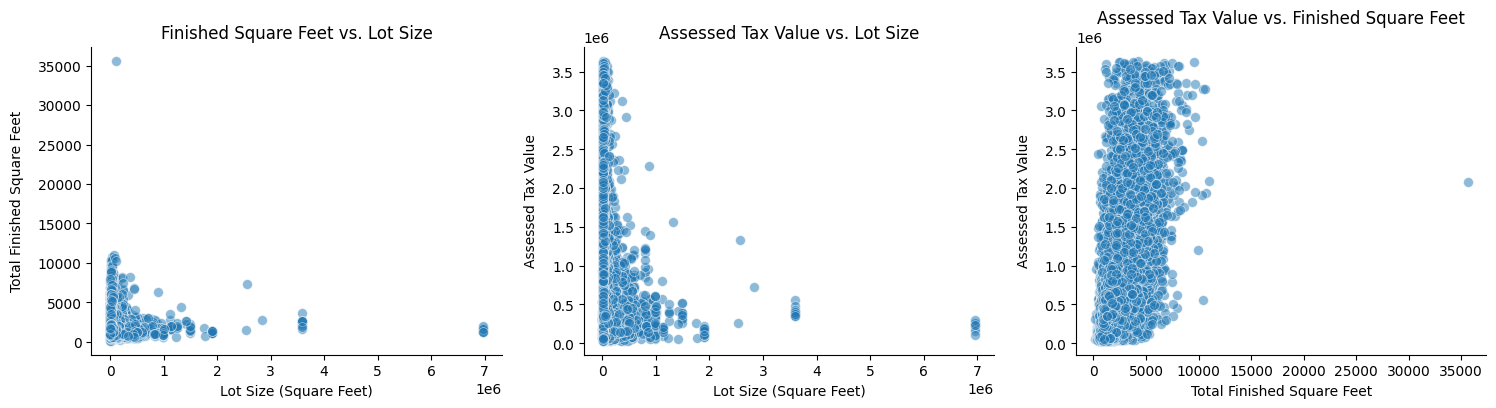

In [6]:
# Scatterplots of Finished Square Feet, Lot Size, and Tax Value (Target)

plt.subplots(1, 3, figsize = (18, 4))

plt.subplot(1, 3, 1)

ax = sns.scatterplot(x = "lotsizesquarefeet", y = "calculatedfinishedsquarefeet", data = df_imputed, s = 50, alpha = 0.5)

ax.spines[["top", "right"]].set_color("none")
ax.set_xlabel("Lot Size (Square Feet)")
ax.set_ylabel("Total Finished Square Feet", labelpad = 10)
ax.set_title("Finished Square Feet vs. Lot Size")


plt.subplot(1, 3, 2)

ax = sns.scatterplot(x = "lotsizesquarefeet", y = "taxvaluedollarcnt", data = df_imputed, s = 50, alpha = 0.5)

ax.spines[["top", "right"]].set_color("none")
ax.set_xlabel("Lot Size (Square Feet)")
ax.set_ylabel("Assessed Tax Value", labelpad = 10)
ax.set_title("Assessed Tax Value vs. Lot Size")


plt.subplot(1, 3, 3)

ax = sns.scatterplot(x = "calculatedfinishedsquarefeet", y = "taxvaluedollarcnt", data = df_imputed, s = 50, alpha = 0.5)

ax.spines[["top", "right"]].set_color("none")
ax.set_xlabel("Total Finished Square Feet")
ax.set_ylabel("Assessed Tax Value", labelpad = 10)
ax.set_title("Assessed Tax Value vs. Finished Square Feet")

None

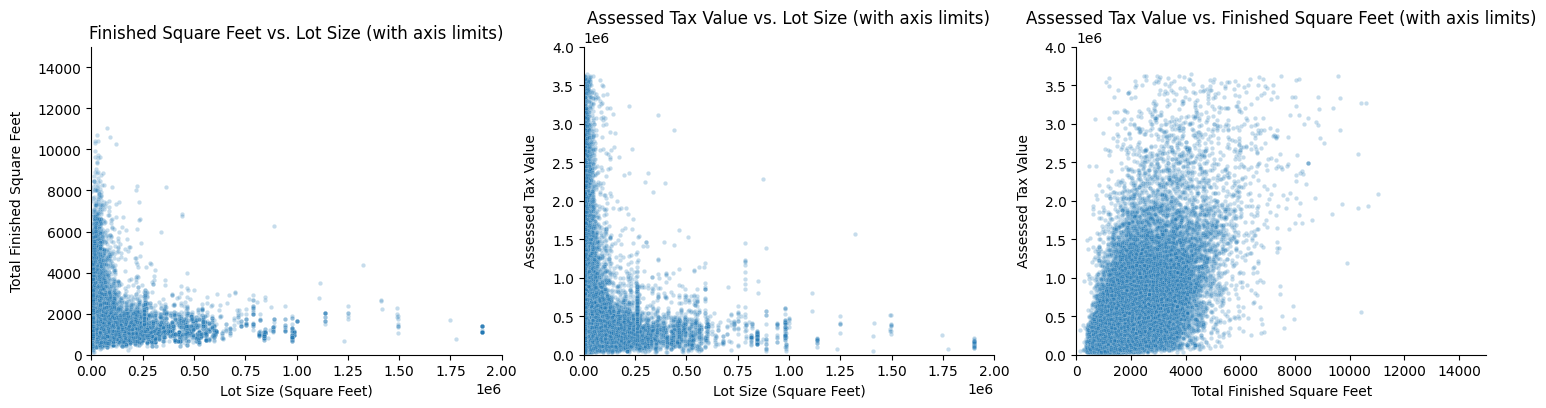

In [7]:
# Same 3 scatter plots with axis limits to ignore large outliers and focus on general trend

plt.subplots(1, 3, figsize = (18, 4))

plt.subplot(1, 3, 1)

ax = sns.scatterplot(x = "lotsizesquarefeet", y = "calculatedfinishedsquarefeet", data = df_imputed, s = 10, alpha = 0.25)

ax.spines[["top", "right"]].set_color("none")
ax.set_xlabel("Lot Size (Square Feet)")
ax.set_ylabel("Total Finished Square Feet", labelpad = 10)
ax.set_title("Finished Square Feet vs. Lot Size (with axis limits)")
ax.set_xlim(0, 2 * 10**6)
ax.set_ylim(0, 15000)


plt.subplot(1, 3, 2)

ax = sns.scatterplot(x = "lotsizesquarefeet", y = "taxvaluedollarcnt", data = df_imputed, s = 10, alpha = 0.25)

ax.spines[["top", "right"]].set_color("none")
ax.set_xlabel("Lot Size (Square Feet)")
ax.set_ylabel("Assessed Tax Value", labelpad = 10)
ax.set_title("Assessed Tax Value vs. Lot Size (with axis limits)")
ax.set_xlim(0, 2 * 10**6)
ax.set_ylim(0, 4 * 10**6)


plt.subplot(1, 3, 3)

ax = sns.scatterplot(x = "calculatedfinishedsquarefeet", y = "taxvaluedollarcnt", data = df_imputed, s = 10, alpha = 0.25)

ax.spines[["top", "right"]].set_color("none")
ax.set_xlabel("Total Finished Square Feet")
ax.set_ylabel("Assessed Tax Value", labelpad = 10)
ax.set_title("Assessed Tax Value vs. Finished Square Feet (with axis limits)")
ax.set_xlim(0, 15000)
ax.set_ylim(0, 4 * 10**6)

None

**Discussion:**

For the three scatter plots above, the axis limits are again adjusted to ignore the larger outliers and focus on the general trend of the data.

1.   Plot 1 - here we compare the relationship between `lotsizesquarefeet` and `calculatedfinishedsquarefeet`, which has a linear correlation close to 0. Would it not make sense for larger houses to be on larger plots of land? From the scatter plot, it appears a relationship does exist, but that it is not linear, and might instead fit an exponential or polynomial curve. We may need to try some feature transformations as part of our analysis to capture these non-linear relationships.

2.   Plot 2 - here we compare the relationship between `lotsizesquarefeet` and the target variable `taxvaluedollarcnt`, which also had a linear correlation close to 0. Similar to Plot 1, we can see that a relationship does exist between Lot Size and the Assessed Tax Value (which makes sense), but that the relationship is not linear and follows an exponential or polynomial curve.

3.  Plot 3 - here we compare the relationship between `calculatedfinishedsquarefeet` and the target variable `taxvaluedollarcnt`, which had a positive linear correlation of 0.59. The plot shows a general linear trend of larger houses carrying a greater assessed value.

**PART 5: Feature Engineering**

**1. Log-Transform and Normalize Features**

In [148]:
# Define Features and Target

X = df_imputed.drop(["propertycountylandusecode", "propertyzoningdesc", "taxdelinquencyyear", "taxvaluedollarcnt"], axis = 1)
y = df_imputed["taxvaluedollarcnt"]

In [149]:
# Check for Skewness
from scipy.stats import skew

for feature in X:
  print(f"{feature}: {skew(X[feature]):.3f}")

bathroomcnt: 1.124
bedroomcnt: 0.806
buildingqualitytypeid: -0.062
calculatedbathnbr: 1.196
calculatedfinishedsquarefeet: 2.644
finishedsquarefeet12: 1.970
fireplacecnt: 3.689
fullbathcnt: 1.252
garagecarcnt: -0.312
garagetotalsqft: 0.055
hashottuborspa: 6.957
heatingorsystemtypeid: 1.503
lotsizesquarefeet: 25.485
poolcnt: 1.439
poolsizesum: 0.165
propertylandusetypeid: -17.586
regionidcity: 6.428
regionidcounty: -0.788
regionidneighborhood: 0.604
regionidzip: 85.658
roomcnt: 0.806
threequarterbathnbr: 3.506
unitcnt: 15.152
yearbuilt: -0.305
numberofstories: 0.566
taxdelinquencyflag: 4.919


In [150]:
# Select Skewed Features (skew > 0.75) to Log Transform

skewed_features = ["bathroomcnt", "bedroomcnt", "calculatedbathnbr", "calculatedfinishedsquarefeet", "finishedsquarefeet12",
                    "fireplacecnt", "fullbathcnt", "lotsizesquarefeet", "roomcnt", "threequarterbathnbr"]

In [151]:
# Create Column Transformer for Features

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import FunctionTransformer

preprocessor = ColumnTransformer(transformers = [('log', FunctionTransformer(np.log1p), skewed_features),], remainder = "passthrough")

In [152]:
# Create Log-Transformed Features (drop originals)

X_log = preprocessor.fit_transform(X)

In [153]:
# Scale and Normalize the Features

scaler = StandardScaler()
X_log_scaled = scaler.fit_transform(X_log)

X_log_scaled = pd.DataFrame(X_log_scaled, columns = X.columns)


Features: ['calculatedfinishedsquarefeet'], CV Score (RMSE): 353302.3365

Features: ['calculatedfinishedsquarefeet', 'bedroomcnt'], CV Score (RMSE): 347641.9678

Features: ['calculatedfinishedsquarefeet', 'bedroomcnt', 'numberofstories'], CV Score (RMSE): 344790.2904

Features: ['bedroomcnt', 'numberofstories', 'bathroomcnt'], CV Score (RMSE): 343381.4702

Features: ['numberofstories', 'bathroomcnt', 'poolcnt'], CV Score (RMSE): 342115.3344

Features: ['bathroomcnt', 'poolcnt', 'yearbuilt'], CV Score (RMSE): 341182.2852

Features: ['poolcnt', 'yearbuilt', 'regionidcity'], CV Score (RMSE): 340288.4889

Features: ['yearbuilt', 'regionidcity', 'garagecarcnt'], CV Score (RMSE): 339306.5794

Features: ['regionidcity', 'garagecarcnt', 'lotsizesquarefeet'], CV Score (RMSE): 338566.2580

Features: ['garagecarcnt', 'lotsizesquarefeet', 'regionidcounty'], CV Score (RMSE): 337991.3311

Features: ['lotsizesquarefeet', 'regionidcounty', 'garagetotalsqft'], CV Score (RMSE): 337619.7382

Features: [

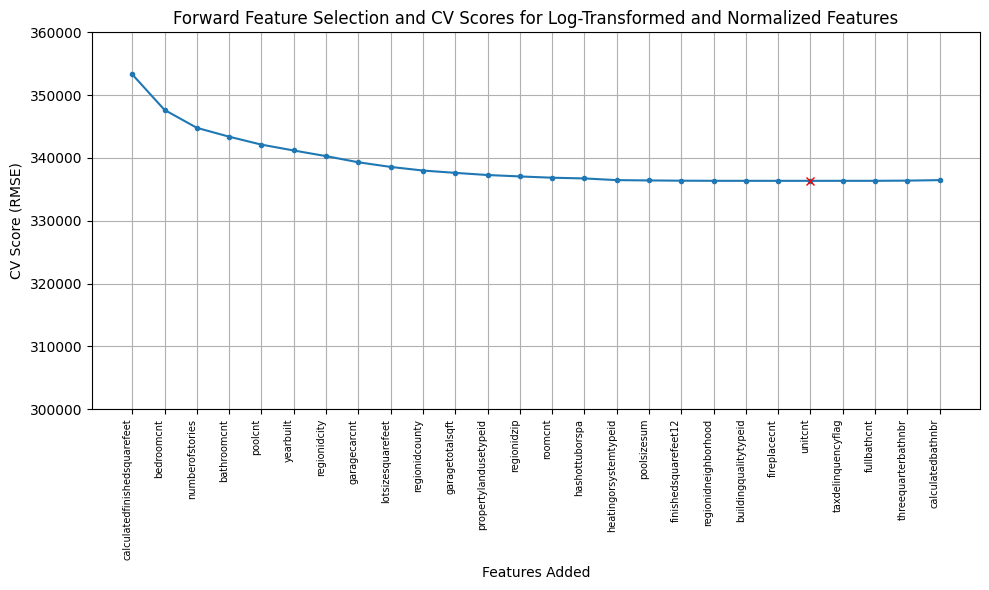

Best Features: ['calculatedfinishedsquarefeet', 'bedroomcnt', 'numberofstories', 'bathroomcnt', 'poolcnt', 'yearbuilt', 'regionidcity', 'garagecarcnt', 'lotsizesquarefeet', 'regionidcounty', 'garagetotalsqft', 'propertylandusetypeid', 'regionidzip', 'roomcnt', 'hashottuborspa', 'heatingorsystemtypeid', 'poolsizesum', 'finishedsquarefeet12', 'regionidneighborhood', 'buildingqualitytypeid', 'fireplacecnt', 'unitcnt']
Best CV Score: 336349.7488


In [137]:
# Run Forward Feature Selection with Log Scaled Data

from sklearn.linear_model import LinearRegression

model = LinearRegression()

selected_features, best_scores, best_forward_features, best_forward_score = (forward_feature_selection(X_log_scaled, y, model, verbose = True))

# Plot the results

index = np.argmax(np.array(selected_features) == best_forward_features[-1])

plt.figure(figsize = (10, 6))
plt.plot(range(1, len(best_scores) + 1), best_scores, marker = '.')
plt.plot([index + 1], best_forward_score, marker = 'x', color = 'red')
plt.xticks(range(1, len(selected_features) + 1), selected_features, rotation = 90, ha = 'right', fontsize = 7)
plt.title('Forward Feature Selection and CV Scores for Log-Transformed and Normalized Features')
plt.xlabel('Features Added')
plt.ylabel('CV Score (RMSE)')
plt.grid()

# Change scale of y-axis to better see better see the behavior around the minimum point
plt.ylim(300000, 360000)

plt.tight_layout()
plt.show()

# Print the best subset and score
print(f"Best Features: {best_forward_features}")
print(f"Best CV Score: {best_forward_score:.4f}")

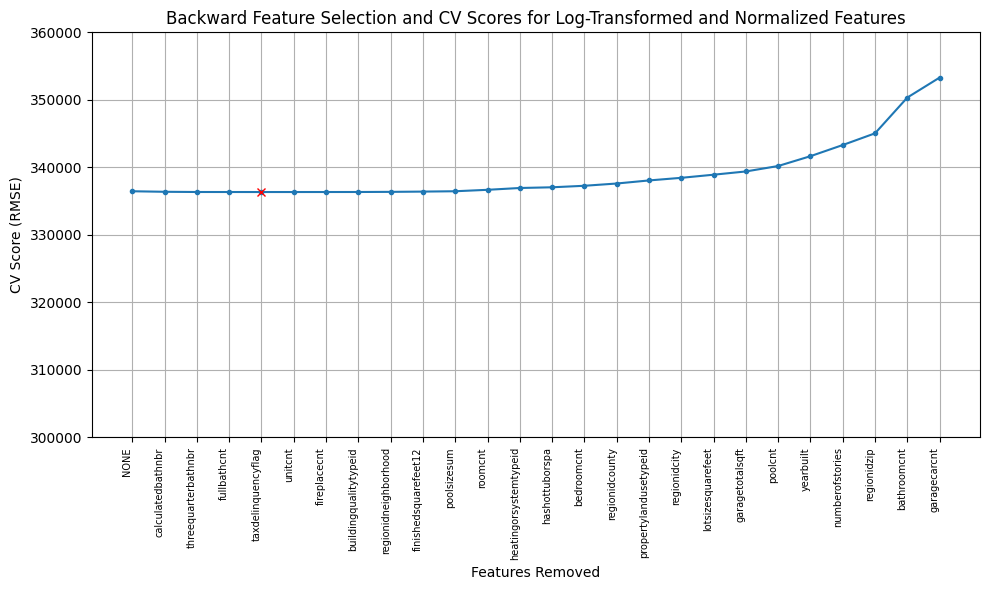

Best feature set: ['bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'fireplacecnt', 'garagecarcnt', 'garagetotalsqft', 'hashottuborspa', 'heatingorsystemtypeid', 'lotsizesquarefeet', 'poolcnt', 'poolsizesum', 'propertylandusetypeid', 'regionidcity', 'regionidcounty', 'regionidneighborhood', 'regionidzip', 'roomcnt', 'unitcnt', 'yearbuilt', 'numberofstories']
CV score (RMSE): 336349.7488


In [138]:
# Run Backward Feature Selection with Log Scaled Data

model = LinearRegression()

selected_features, best_scores, best_feature_set, best_backward_score = (backward_feature_selection(X_log_scaled, y, model, verbose = False))

# Plot the results

plt.figure(figsize = (10, 6))
plt.title('Backward Feature Selection and CV Scores for Log-Transformed and Normalized Features')
plt.plot(range(1, len(best_scores) + 1), best_scores, marker = '.')
index = np.argmin(best_scores)
plt.plot([index + 1], best_scores[index], marker = 'x', color = 'red')
plt.xticks(range(1, len(selected_features) + 1), selected_features, rotation = 90, ha = 'right', fontsize=7)
plt.xlabel('Features Removed')
plt.ylabel('CV Score (RMSE)')

plt.ylim(300000, 360000)

plt.grid()
plt.tight_layout()
plt.show()

# Print the best subset and cv score

print("Best feature set:", best_feature_set)
print("CV score (RMSE):", np.around(best_backward_score, 4))

**Discussion:**

The histograms constructed in Part 2 showed several features have a strong right-skew with some large outliers. As a result, we thought that a log-transform of the skewed features might help to improve our model. We calculated skew and selected the quantitaive features with a skew value of at least 0.75. Non-ordinal numeric features like `regionidzip`, among others, were not considered for the log-transform.

We identified and log-transformed 10 features, and then re-ran forward and backward feature selection on the entire set of features. While the number of features selected increased, surprisingly the best RMSE also increased, indicating the the non-log transformed features might give us a better model.

**2. Polynomial-Transform and Normalize Features:**

In [81]:
# Select Fewer (9) Features

X_9features = X[["calculatedfinishedsquarefeet", "bedroomcnt", "bathroomcnt", "roomcnt", "numberofstories", "fireplacecnt", "poolcnt", "garagetotalsqft", "lotsizesquarefeet"]]

In [82]:
# Create Polynomial-Transformed Features (keep originals and add poynomial)

from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree = 2, include_bias = False)

X_poly = poly.fit_transform(X_9features)

In [83]:
# Scale and Normalize the Features

scaler = StandardScaler()

X_poly_scaled = scaler.fit_transform(X_poly)

X_poly_scaled = pd.DataFrame(X_poly_scaled, columns = poly.get_feature_names_out(X_9features.columns))


Features: ['calculatedfinishedsquarefeet numberofstories'], CV Score (RMSE): 334832.7423

Features: ['calculatedfinishedsquarefeet numberofstories', 'calculatedfinishedsquarefeet bathroomcnt'], CV Score (RMSE): 329070.8639

Features: ['calculatedfinishedsquarefeet numberofstories', 'calculatedfinishedsquarefeet bathroomcnt', 'bedroomcnt numberofstories'], CV Score (RMSE): 324928.1264

Features: ['calculatedfinishedsquarefeet bathroomcnt', 'bedroomcnt numberofstories', 'poolcnt garagetotalsqft'], CV Score (RMSE): 324283.9758

Features: ['bedroomcnt numberofstories', 'poolcnt garagetotalsqft', 'bathroomcnt'], CV Score (RMSE): 323856.4369

Features: ['poolcnt garagetotalsqft', 'bathroomcnt', 'bathroomcnt roomcnt'], CV Score (RMSE): 323395.5315

Features: ['bathroomcnt', 'bathroomcnt roomcnt', 'calculatedfinishedsquarefeet'], CV Score (RMSE): 322960.9328

Features: ['bathroomcnt roomcnt', 'calculatedfinishedsquarefeet', 'bathroomcnt numberofstories'], CV Score (RMSE): 322304.0575

Feature

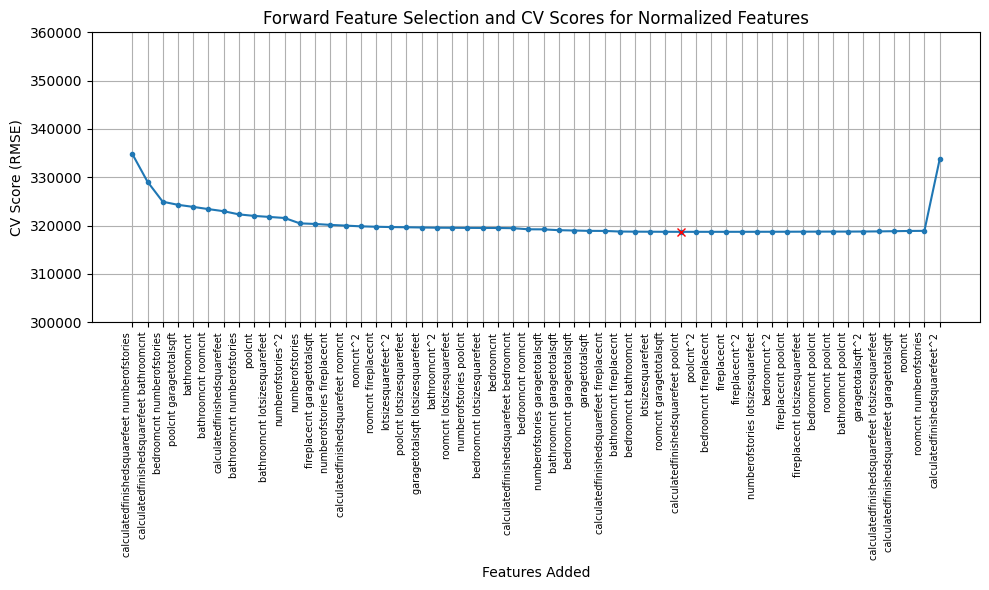

Best Features: ['calculatedfinishedsquarefeet numberofstories', 'calculatedfinishedsquarefeet bathroomcnt', 'bedroomcnt numberofstories', 'poolcnt garagetotalsqft', 'bathroomcnt', 'bathroomcnt roomcnt', 'calculatedfinishedsquarefeet', 'bathroomcnt numberofstories', 'poolcnt', 'bathroomcnt lotsizesquarefeet', 'numberofstories^2', 'numberofstories', 'fireplacecnt garagetotalsqft', 'numberofstories fireplacecnt', 'calculatedfinishedsquarefeet roomcnt', 'roomcnt^2', 'roomcnt fireplacecnt', 'lotsizesquarefeet^2', 'poolcnt lotsizesquarefeet', 'garagetotalsqft lotsizesquarefeet', 'bathroomcnt^2', 'roomcnt lotsizesquarefeet', 'numberofstories poolcnt', 'bedroomcnt lotsizesquarefeet', 'bedroomcnt', 'calculatedfinishedsquarefeet bedroomcnt', 'bedroomcnt roomcnt', 'numberofstories garagetotalsqft', 'bathroomcnt garagetotalsqft', 'bedroomcnt garagetotalsqft', 'garagetotalsqft', 'calculatedfinishedsquarefeet fireplacecnt', 'bathroomcnt fireplacecnt', 'bedroomcnt bathroomcnt', 'lotsizesquarefeet', '

In [85]:
# Run Forward Feature Selection with Polynomial Scaled Data

from sklearn.linear_model import LinearRegression

model = LinearRegression()

selected_features, best_scores, best_forward_features, best_forward_score = (forward_feature_selection(X_poly_scaled, y, model, verbose = True))

# Plot the results

index = np.argmax(np.array(selected_features) == best_forward_features[-1])

plt.figure(figsize = (10, 6))
plt.plot(range(1, len(best_scores) + 1), best_scores, marker = '.')
plt.plot([index + 1], best_forward_score, marker = 'x', color = 'red')
plt.xticks(range(1, len(selected_features) + 1), selected_features, rotation = 90, ha = 'right', fontsize = 7)
plt.title('Forward Feature Selection and CV Scores for Polynomial-Transformed and Normalized Features')
plt.xlabel('Features Added')
plt.ylabel('CV Score (RMSE)')
plt.grid()

# Change scale of y-axis to better see better see the behavior around the minimum point
plt.ylim(300000, 360000)

plt.tight_layout()
plt.show()

# Print the best subset and score
print(f"Best Features: {best_forward_features}")
print(f"Best CV Score: {best_forward_score:.4f}")

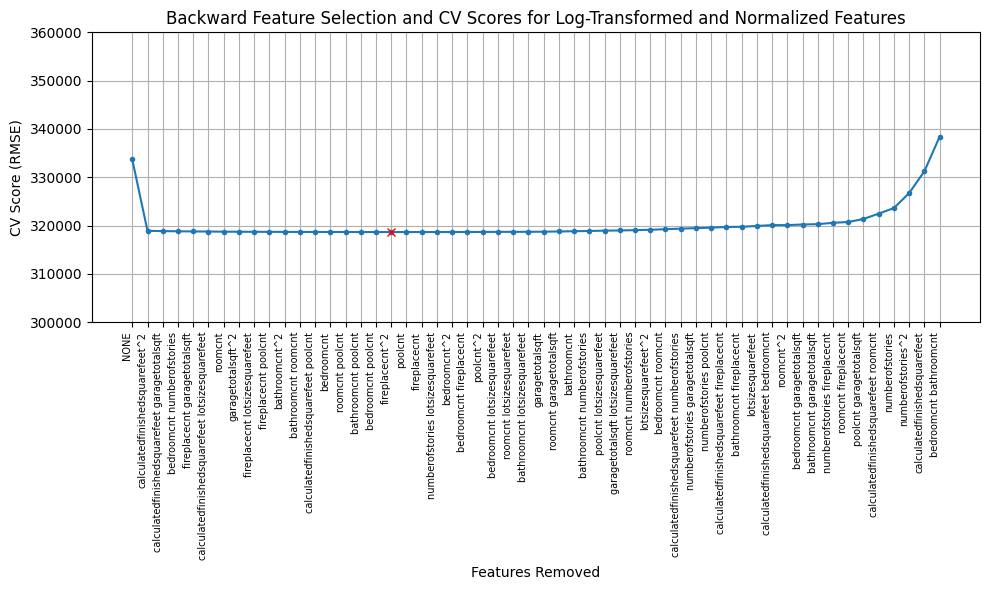

Best feature set: ['calculatedfinishedsquarefeet', 'bathroomcnt', 'numberofstories', 'fireplacecnt', 'poolcnt', 'garagetotalsqft', 'lotsizesquarefeet', 'calculatedfinishedsquarefeet bedroomcnt', 'calculatedfinishedsquarefeet bathroomcnt', 'calculatedfinishedsquarefeet roomcnt', 'calculatedfinishedsquarefeet numberofstories', 'calculatedfinishedsquarefeet fireplacecnt', 'bedroomcnt^2', 'bedroomcnt bathroomcnt', 'bedroomcnt roomcnt', 'bedroomcnt fireplacecnt', 'bedroomcnt garagetotalsqft', 'bedroomcnt lotsizesquarefeet', 'bathroomcnt numberofstories', 'bathroomcnt fireplacecnt', 'bathroomcnt garagetotalsqft', 'bathroomcnt lotsizesquarefeet', 'roomcnt^2', 'roomcnt numberofstories', 'roomcnt fireplacecnt', 'roomcnt garagetotalsqft', 'roomcnt lotsizesquarefeet', 'numberofstories^2', 'numberofstories fireplacecnt', 'numberofstories poolcnt', 'numberofstories garagetotalsqft', 'numberofstories lotsizesquarefeet', 'poolcnt^2', 'poolcnt garagetotalsqft', 'poolcnt lotsizesquarefeet', 'garagetota

In [99]:
# Run Backward Feature Selection with Polynomial Scaled Data

model = LinearRegression()

selected_features, best_scores, best_feature_set, best_backward_score = (backward_feature_selection(X_poly_scaled, y, model, verbose = False))

# Plot the results

plt.figure(figsize = (10, 6))
plt.title('Backward Feature Selection and CV Scores for Log-Transformed and Normalized Features')
plt.plot(range(1, len(best_scores) + 1), best_scores, marker = '.')
index = np.argmin(best_scores)
plt.plot([index + 1], best_scores[index], marker = 'x', color = 'red')
plt.xticks(range(1, len(selected_features) + 1), selected_features, rotation = 90, ha = 'right', fontsize=7)
plt.xlabel('Features Removed')
plt.ylabel('CV Score (RMSE)')

plt.ylim(300000, 360000)

plt.grid()
plt.tight_layout()
plt.show()

# Print the best subset and cv score

print("Best feature set:", best_feature_set)
print("CV score (RMSE):", np.around(best_backward_score, 4))

**Discussion:**

Since our work in Part 4 showed that some features had non-linear relationships both to each other and the target variable, we thought it would be wise to explore the effect of a polynomial transformation of some of the features.

To avoid feature explosion, we selected nine quantitative features of interest, and proceeded to and proceeded to apply a polynomial transformation to each variable. We kept the original features and included interactions between features and features-squared, so our total feature count expanded to 54.

Both forward and backward feature selection yielded lower RMSE scores than any of our previous attempts, with the backward selection score of 318643.4976 being the best.

It seems that polynomial feature transformation might be something for us to consider as we build our model.